In [12]:
#############################################
"""
1. This file Generate the Dataset for training
"""

'\n1. This file Generate the Dataset for training\n'

In [13]:
import numpy as np
import matplotlib.pyplot as plt
# add parent folder (production) to sys.path
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.LoRa import LoRa

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
fs = 1000000   # 1 MHz
bw = 125e3          # LoRa Bandwidth (125 kHz)
sf = 9       # Spreading Factor 

symbol_time = 2**sf / bw  # Symbol duration
N = 2**sf

input_row = 512
input_col = 33

In [ ]:
# GENERATE NEW DATASET (ONCE)
GEENRATE_ = True
SNR_first = 15
SNR_last = -30

lora_init = LoRa(sf, bw)

if (GEENRATE_):

    folder_path = f"dataset_sf{sf}_{input_row}x{input_col}"

    # Check if folder exists, if not create it
    check_and_make_folder(folder_path)
    # Outer loop: from 15 to -30 (inclusive)
    for i in range(SNR_first, SNR_last, -1):  # step -1 to count down
        # Inner loop: 100 iterations
        for j in range(N): # 0 until 2**sf
            x1 = lora_init.gen_symbol_fs(j, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6
            snr = i
            x = lora_init.awgn_iq(x1,snr)
            #### DOWNSAMPLING
            create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,i,j,1,folder_path)
       

Folder created: dataset_sf9_512x33


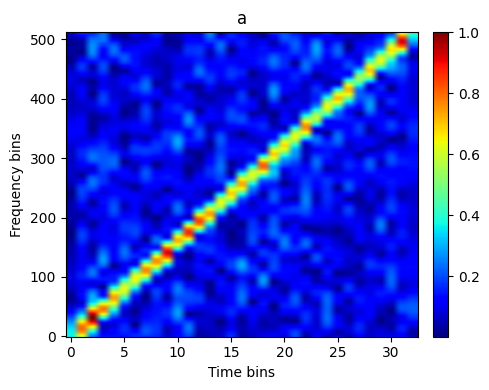

(512, 33)
float64
0.14711294974396122
0.001028785870669821
0.9999999999999999


In [16]:
file_path = f"dataset_sf{sf}_{input_row}x{input_col}/s_sf{sf}_bw125_-7_0_1.npy"  # example path
data2 = np.load(file_path)

show_multiple_spectrograms([data2],["a"],1)
print(data2.shape)
print(data2.dtype)
print(data2.mean())
print(data2.min())
print(data2.max())